<a href="https://colab.research.google.com/github/jfpa11100/E-Sports-ML/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto 1: E-Sports Biometrics & Performance**
## Predicción del resultado de partidas (Win/Loss) a partir de biométricas y métricas ambientales de jugadores de e-sports

**Curso:** Inteligencia Artificial

**Universidad:** Universidad de Medellín (UdeM)

**Profesor:** Antonio Jesús Tamayo Herrera

**Semestre:** 2026-1

**Integrantes:**
- Mariana Pineda Isaza
- Juan Pablo Ramírez
- Juan Felipe Palacio

---

### **Descripción del proyecto**

Este proyecto utiliza el dataset **[E-Sports Biometrics & Performance](https://www.kaggle.com/datasets/sarveshchhetri/e-sports-biometrics-and-performance)** de Kaggle, un conjunto de datos sintético de 250,000 registros diseñado para simular factores fisiológicos y ambientales reales que afectan a atletas de e-sports (élite y casuales).

El dataset mide cómo métricas biológicas como el ritmo cardíaco, la fatiga y el sueño impactan el rendimiento dentro del juego y el resultado de las partidas, un tema relevante para la ciencia del deporte aplicada a los e-sports, un campo en crecimiento junto con la industria.

**Problema:** Clasificación binaria — predecir la variable `Match_Outcome` (Win / Loss) a partir del estado biológico y ambiental de un jugador previo a la partida (edad, horas de sueño, energizantes consumidos, brillo de pantalla, ritmo cardíaco, HRV, APM, tiempo de reacción, entre otras).

### **Descripción del dataset:**

| Column_Name       | Description                                                                                                                                          |
|-------------------|------------------------------------------------------------------------------------------------------------------------------------------------------|
| Player_ID         | A unique alphanumeric identifier for each gamer.                                                                                                     |
| Age               | The age of the player, ranging from 16 to 40 years old.                                                                                              |
| Game_Genre        | The category of the game played during the session (MOBA, FPS, Battle Royale, or Fighting).                                                          |
| PlayTime_Hours    | The duration of the current gaming session in hours, used to measure fatigue.                                                                        |
| Sleep_Hours       | The number of hours the player slept the night before the session.                                                                                   |
| Energy_Drinks     | The number of energy drinks (caffeine) consumed before or during the match.                                                                          |
| Screen_Brightness | The brightness setting of the player's monitor as a percentage (contains ~5% missing values).                                                        |
| Blue_Light_Filter | Indicates whether a blue light filter was active on the screen (Yes / No).                                                                           |
| APM               | Actions Per Minute. A measure of how many inputs (clicks/keystrokes) the player performs per minute.                                                 |
| Heart_Rate_BPM    | The player's average heart rate in beats per minute during the match.                                                                                |
| HRV_Score         | Heart Rate Variability score (10-100). Higher scores generally indicate less physiological stress and better recovery (contains ~2% missing values). |
| Reaction_Time_ms  | The player's average reaction time measured in milliseconds (ms).                                                                                    |
| Match_Outcome     | The final result of the gaming match (Win / Loss).                                                                                                   |


### **Tipo de cada variable:**

- **Numéricas continuas:** `Age`, `PlayTime_Hours`, `Sleep_Hours`, `Energy_Drinks`, `Screen_Brightness`, `APM`, `Heart_Rate_BPM`, `HRV_Score`, `Reaction_Time_ms`
- **Categórica nominal:** `Game_Genre` (4 categorías: MOBA, FPS, Battle Royale, Fighting)
- **Binarias:** `Blue_Light_Filter` (Yes/No), `Match_Outcome` (Win/Loss — variable objetivo)
- **Identificador (se descarta):** `Player_ID`

## **Análisis exploratorio de datos (EDA)**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [19]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
url_csv = "https://raw.githubusercontent.com/jfpa11100/E-Sports-ML/main/data/esports_gaming_biometrics_250k.csv"

try:
    df = pd.read_csv(url_csv)
    print("Dataset cargado exitosamente desde GitHub.")
    display(df.head())
except Exception as e:
    print(f"Error al cargar el dataset desde GitHub: {e}")
    df = pd.DataFrame()

Dataset cargado exitosamente desde GitHub.


,Player_ID,Age,Game_Genre,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,Blue_Light_Filter,APM,Heart_Rate_BPM,HRV_Score,Reaction_Time_ms,Match_Outcome
0,PL_000001,24,FPS,1.41,8.88,0,43.4,Yes,107,78,95.02,268.96,Loss
1,PL_000002,22,FPS,4.43,7.45,2,88.0,Yes,110,102,82.92,281.90,Win
2,PL_000003,25,Battle Royale,3.75,8.10,1,24.8,Yes,152,96,89.13,288.57,Win
3,PL_000004,29,FPS,1.76,6.69,0,80.2,No,151,65,80.41,279.76,Win
4,PL_000005,22,FPS,5.79,8.17,1,34.4,No,148,95,95.71,229.62,Loss


In [21]:
# Eliminamos el Player_ID ya que no aporta al modelo
df = df.drop(columns=['Player_ID'], errors='ignore')

In [22]:
df.describe()

,Age,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,APM,Heart_Rate_BPM,HRV_Score,Reaction_Time_ms
count,250000.000000,250000.000000,250000.000000,250000.000000,237452.000000,250000.000000,250000.000000,245066.000000,250000.000000
mean,22.588136,2.527753,6.500900,0.917720,54.918735,204.076168,84.062784,87.479087,262.900538
std,3.829706,2.358799,1.495851,1.045559,25.965989,77.004233,9.670229,11.063101,19.096927
min,16.000000,0.500000,2.000000,0.000000,10.000000,30.000000,60.000000,25.510000,175.170000
25%,20.000000,0.720000,5.490000,0.000000,32.500000,143.000000,77.000000,80.590000,249.930000
50%,23.000000,1.730000,6.500000,1.000000,54.900000,192.000000,84.000000,89.190000,262.590000
75%,25.000000,3.470000,7.510000,1.000000,77.400000,263.000000,90.000000,97.260000,275.600000
max,40.000000,12.000000,11.000000,4.000000,100.000000,563.000000,129.000000,100.000000,355.470000


### **Verificación de los rangos declarados en la tabla de descripción**

In [23]:
print("Rango de Age:", df['Age'].min(), "-", df['Age'].max())
print("Rango de Sleep_Hours:", df['Sleep_Hours'].min(), "-", df['Sleep_Hours'].max())
print("Rango de HRV_Score:", df['HRV_Score'].min(), "-", df['HRV_Score'].max())

Rango de Age: 16 - 40
Rango de Sleep_Hours: 2.0 - 11.0
Rango de HRV_Score: 25.51 - 100.0


**Análisis:** Los rangos reales coinciden con lo documentado: `Age` va de 16 a 40 años tal como se indicó.
`Sleep_Hours` va de 2.0 a 11.0 horas (rango fisiológicamente razonable). `HRV_Score` va de 25.51 a 100.0 — el
límite superior de 100 aparece con mucha frecuencia (ver histograma más abajo).

### **Balance de la variable de salida**

In [24]:
df['Match_Outcome'].value_counts(normalize=True)

,proportion
Match_Outcome,
Loss,0.519376
Win,0.480624


**Análisis:** La variable de salida está prácticamente balanceada: **51.9% Loss / 48.1% Win**. Esto es
importante porque significa que no necesitamos técnicas de balanceo ni preocuparnos de que accuracy sea engañosa por desbalance.

### **Distribuciones de las variables categóricas**

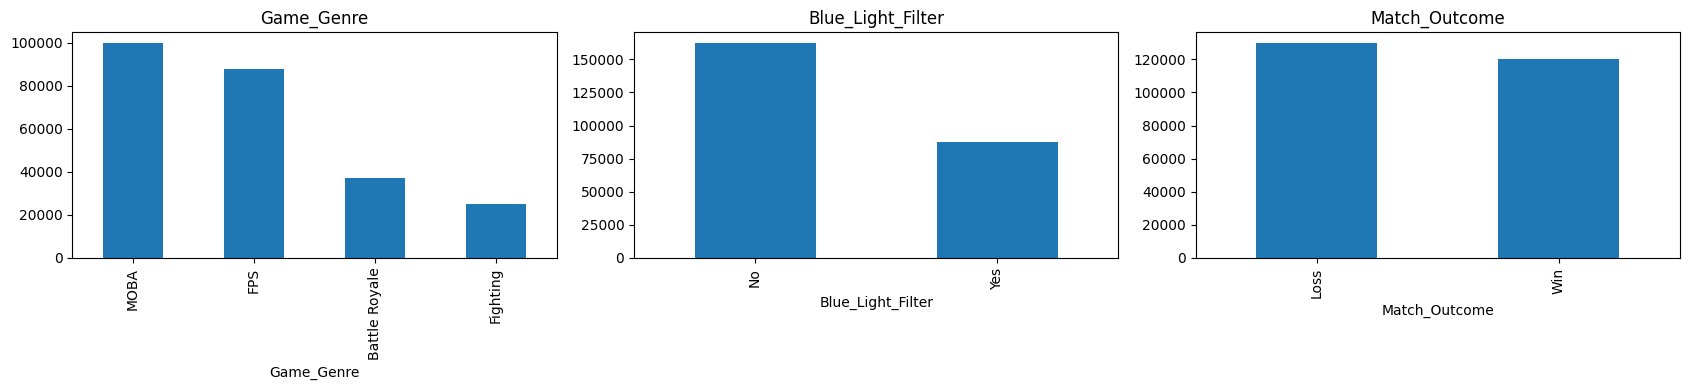

In [25]:
cat_cols = ['Game_Genre', 'Blue_Light_Filter', 'Match_Outcome']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(17, 4))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Análisis:** `Game_Genre` no está balanceado entre sus 4 categorías: MOBA y FPS dominan, mientras que Battle Royale y Fighting están mucho menos representadas. Esto no es un problema para el modelo, pero significa que las predicciones para esas dos categorías se apoyan en menos ejemplos `Blue_Light_Filter` está aproximadamente 65% No / 35% Yes. `Match_Outcome` confirma el balance casi 50/50 visto arriba.

### **Distribuciones de las variables numéricas**

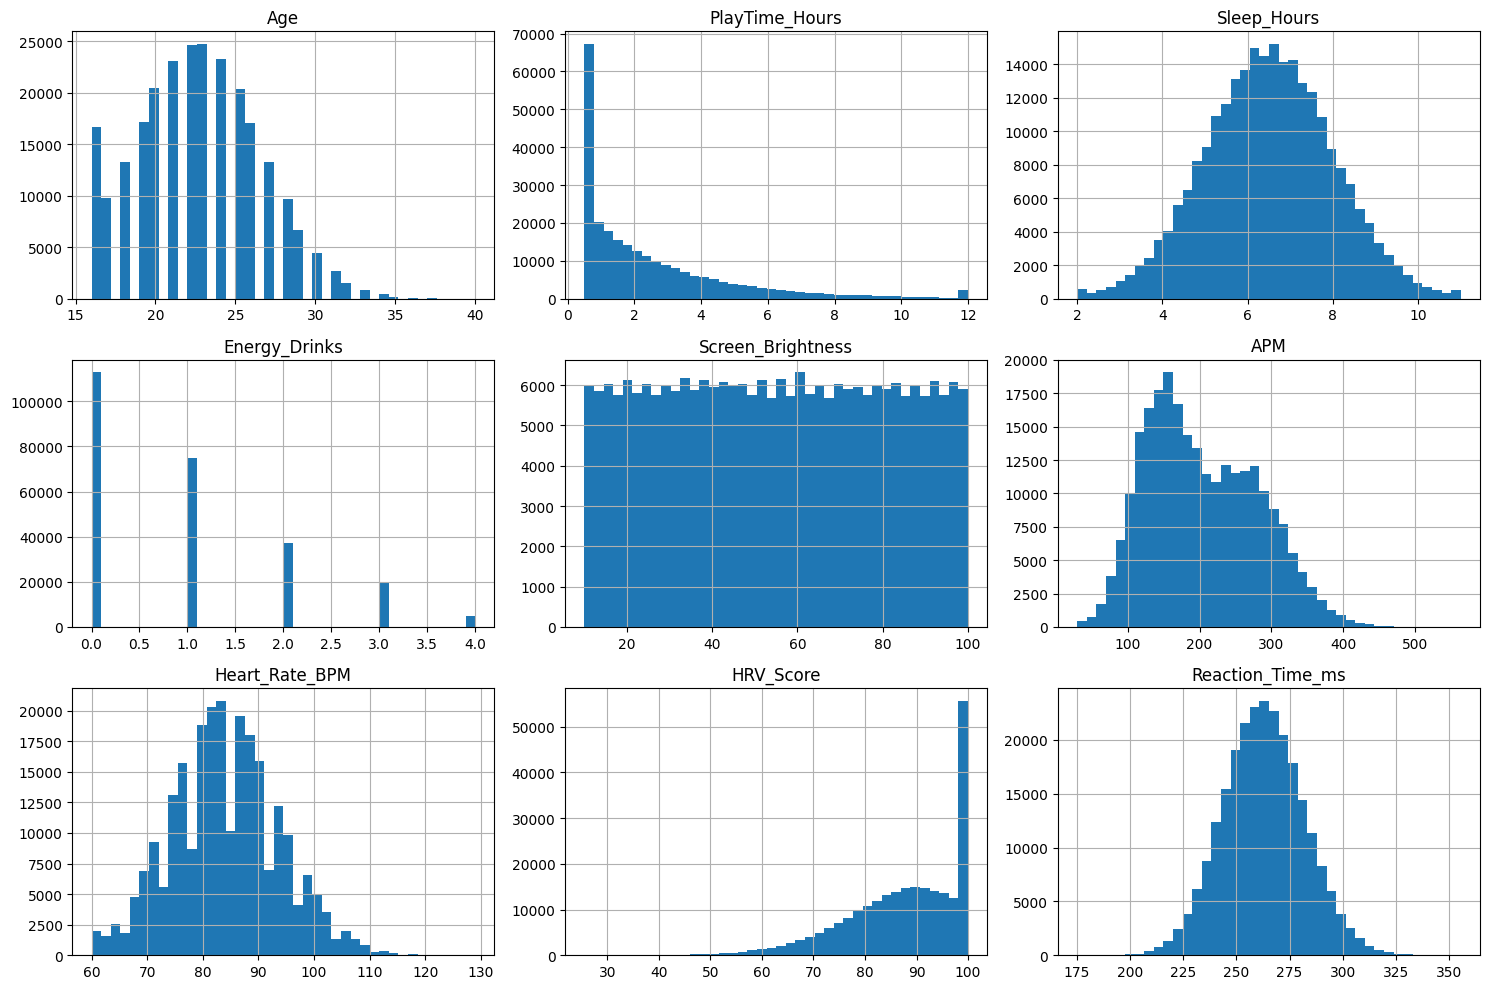

In [26]:
num_cols = ['Age', 'PlayTime_Hours', 'Sleep_Hours', 'Energy_Drinks',
            'Screen_Brightness', 'APM', 'Heart_Rate_BPM', 'HRV_Score', 'Reaction_Time_ms']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    df[col].hist(bins=40, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**Análisis:** las variables numéricas tienen formas muy distintas entre sí, lo que confirma la necesidad de escalar antes de entrenar (especialmente para SVM):
- `Sleep_Hours`, `Heart_Rate_BPM` y `Reaction_Time_ms` tienen forma aproximadamente normal/simétrica.
- `PlayTime_Hours` está fuertemente sesgada a la derecha (la mayoría de sesiones dura menos de 2 horas, con una cola larga hasta 12h), típico de tiempos de duración de eventos.
- `HRV_Score` está sesgada a la izquierda, con una acumulación notoria en el valor máximo, esto según lo consultado, se trata de *ceiling
  effect*.
- `Energy_Drinks` es una variable discreta (0 a 4 bebidas), con la mayoría de jugadores en 0 o 1.
- `Screen_Brightness` se ve prácticamente **uniforme** entre 10 y 100, consistente con ser un ajuste manual del
  usuario sin un valor "típico" preferido.
- `APM` tiene sesgo moderado a la derecha, con la mayoría de jugadores entre 100 y 300 acciones por minuto.

### **Relación de cada variable numérica con el resultado de la partida**

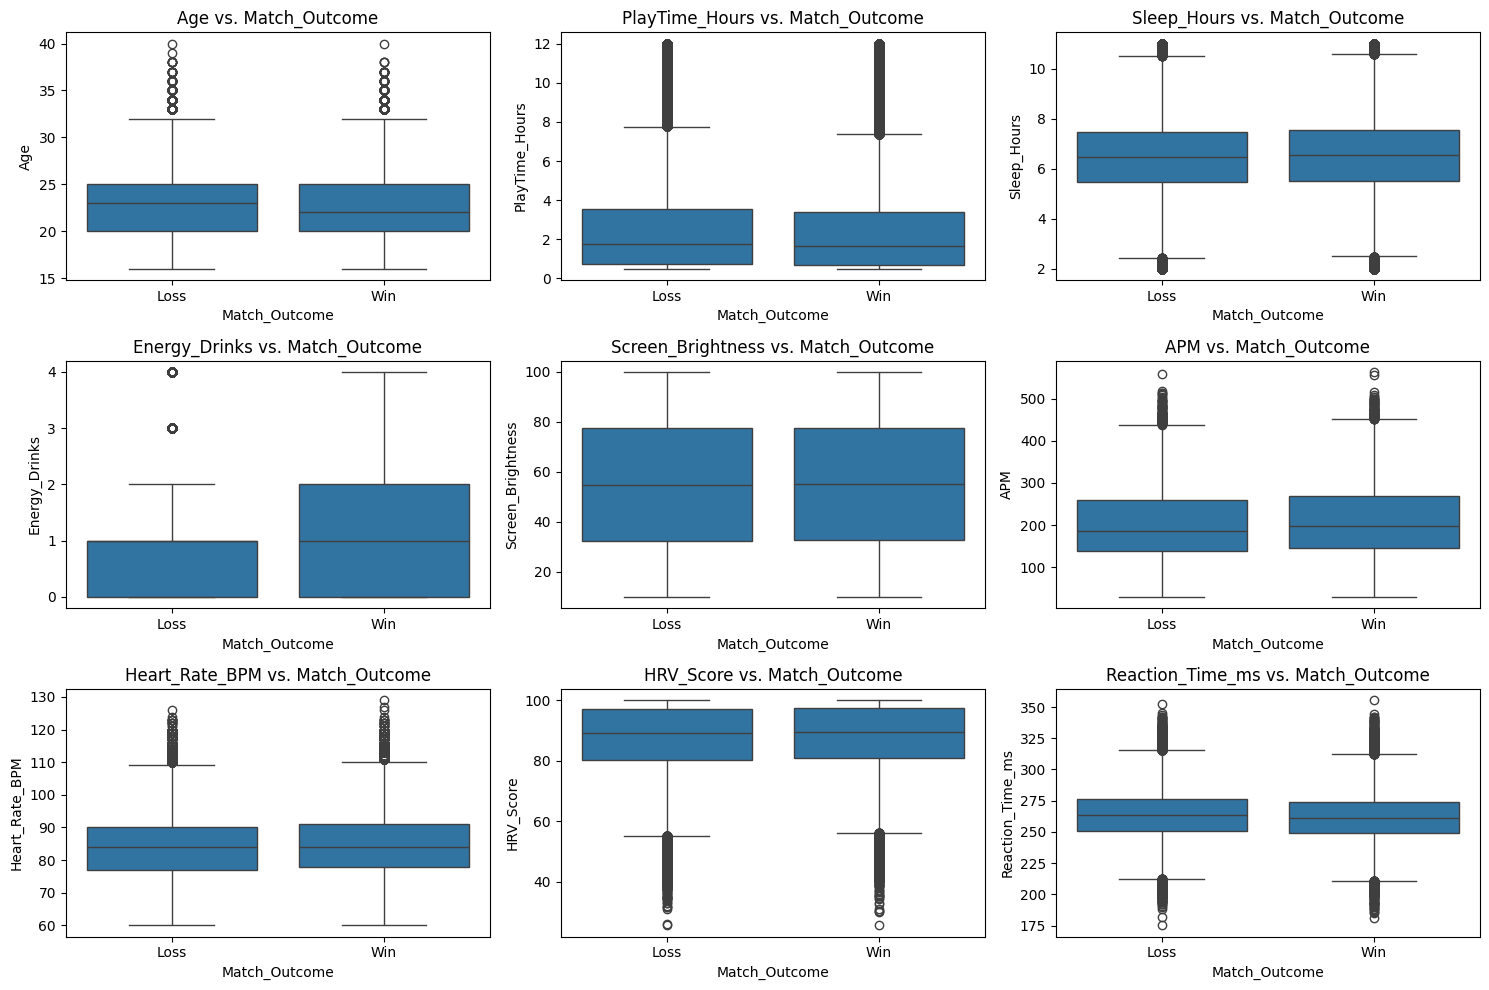

Match_Outcome            Loss         Win
Age                 22.648440   22.522970
PlayTime_Hours       2.587483    2.463207
Sleep_Hours          6.474550    6.529374
Energy_Drinks        0.908583    0.927594
Screen_Brightness   54.842955   55.000619
APM                200.430963  208.015280
Heart_Rate_BPM      83.880541   84.259721
HRV_Score           87.288741   87.684773
Reaction_Time_ms   263.942624  261.774430


In [27]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.boxplot(x='Match_Outcome', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs. Match_Outcome')
plt.tight_layout()
plt.show()

print(df.groupby('Match_Outcome')[num_cols].mean().T)

**Análisis:**

- Al comparar las cajas de Win vs. Loss en cada variable, se ven casi superpuestas, es decir, ninguna biométrica por sí sola permite distinguir claramente si un jugador va a ganar o perder.
- La diferencia más notoria entre clases está en **APM** (Win ≈ 208 vs. Loss ≈ 200, una diferencia de ≈7.5 unidades).
- En menor medida, también se ve en `Reaction_Time_ms` (Win ≈ 262 ms vs. Loss ≈ 264 ms) — los jugadores ganadores reaccionan levemente más rápido.
- El resto de variables (`Age`, `Sleep_Hours`, `Heart_Rate_BPM`, `HRV_Score`, `Screen_Brightness`, `Energy_Drinks`) muestran diferencias muy pequeñas entre clases.

**Conclusión preliminar:**
- `APM` parece ser la variable individual con mayor señal predictiva.
- El resto de biométricas, tomadas una por una, aportan poca separación.
- Es posible que el modelo dependa de **combinaciones** de variables (justo lo que la regresión logística y el SVM pueden capturar) más que de una sola variable dominante.

### **Relación de cada variable numérica con el resultado de la partida**

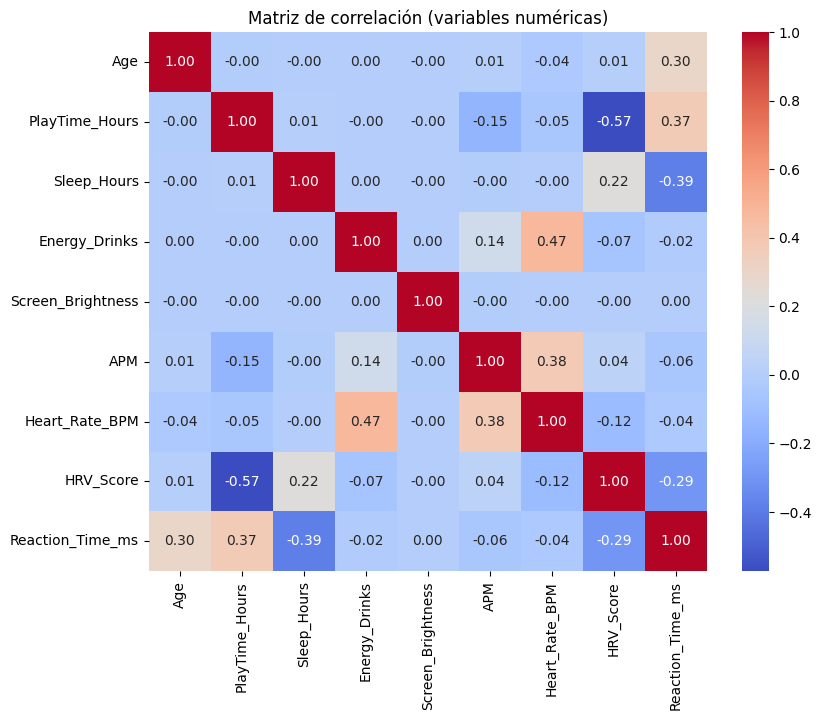

In [28]:
plt.figure(figsize=(9,7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación (variables numéricas)')
plt.show()

**Análisis:** Ninguna correlación entre las variables predictoras supera ≈0.6 en valor absoluto, lo que indica que **no hay
multicolinealidad preocupante**, es decir, las variables no están tan relacionadas entre sí como para
distorsionar la interpretación de los coeficientes cuando entrenemos la regresión logística.

Las correlaciones más fuertes que sí aparecen tienen sentido fisiológico, lo cual es una buena señal de que el
dataset simula relaciones realistas y no ruido aleatorio:

- **Tiempo de juego y variabilidad cardíaca (`PlayTime_Hours` ↔ `HRV_Score`: -0.57):** a medida que un jugador
  lleva más tiempo jugando, su variabilidad cardíaca disminuye, esto se ve como un indicador típico de fatiga acumulada.
- **Energizantes y ritmo cardíaco (`Energy_Drinks` ↔ `Heart_Rate_BPM`: 0.47):** a más bebidas energéticas
  consumidas, mayor ritmo cardíaco, lo cual es el efecto estimulante esperado de la cafeína.
- **Actividad en el juego y ritmo cardíaco (`APM` ↔ `Heart_Rate_BPM`: 0.38):** los jugadores con más acciones
  por minuto también muestran un ritmo cardíaco más alto, reflejando mayor esfuerzo físico y mental.
- **Sueño y tiempo de reacción (`Sleep_Hours` ↔ `Reaction_Time_ms`: -0.39):** dormir más horas se asocia con
  reacciones más rápidas.
- **Fatiga, edad y tiempo de reacción (`PlayTime_Hours` ↔ `Reaction_Time_ms`: 0.37; `Age` ↔ `Reaction_Time_ms`:
  0.30):** tanto jugar por más tiempo como tener más edad se asocian con reacciones más lentas.

### **Tratamiento de valores faltantes**

Analizando los datos, obervamos que `Screen_Brightness` y `HRV_Score` son las únicas variables con datos faltantes. Antes de decidir entre imputar o
eliminar, comparamos explícitamente sus distribuciones y el balance de `Match_Outcome` antes y después.

In [29]:
print("=== ANTES de eliminar nulos ===")
print("Filas totales:", len(df))
print("Nulos en Screen_Brightness:", df['Screen_Brightness'].isnull().sum(),
      f"({100*df['Screen_Brightness'].isnull().mean():.2f}%)")
print("Nulos en HRV_Score:", df['HRV_Score'].isnull().sum(),
      f"({100*df['HRV_Score'].isnull().mean():.2f}%)")
print()
print(df[['Screen_Brightness', 'HRV_Score']].describe())
print()
print(df['Match_Outcome'].value_counts(normalize=True))

=== ANTES de eliminar nulos ===
Filas totales: 250000
Nulos en Screen_Brightness: 12548 (5.02%)
Nulos en HRV_Score: 4934 (1.97%)

       Screen_Brightness      HRV_Score
count      237452.000000  245066.000000
mean           54.918735      87.479087
std            25.965989      11.063101
min            10.000000      25.510000
25%            32.500000      80.590000
50%            54.900000      89.190000
75%            77.400000      97.260000
max           100.000000     100.000000

Match_Outcome
Loss    0.519376
Win     0.480624
Name: proportion, dtype: float64


In [30]:
df_sin_nan = df.dropna()

In [31]:
print("=== DESPUÉS de eliminar nulos ===")
print("Filas eliminadas:", len(df) - len(df_sin_nan),
      f"({100*(len(df)-len(df_sin_nan))/len(df):.2f}%)")
print(df_sin_nan[['Screen_Brightness', 'HRV_Score']].describe())
print()
print(df_sin_nan['Match_Outcome'].value_counts(normalize=True))

=== DESPUÉS de eliminar nulos ===
Filas eliminadas: 17207 (6.88%)
       Screen_Brightness      HRV_Score
count      232793.000000  232793.000000
mean           54.926060      87.483066
std            25.971237      11.062988
min            10.000000      25.510000
25%            32.500000      80.590000
50%            54.900000      89.200000
75%            77.400000      97.270000
max           100.000000     100.000000

Match_Outcome
Loss    0.519341
Win     0.480659
Name: proportion, dtype: float64


**Análisis:**

- **Valores faltantes:** `Screen_Brightness` tiene 12,548 nulos (5.02%) y `HRV_Score` tiene 4,934 nulos (1.97%), con 275 filas que tienen ambos datos faltantes a la vez.
- **Filas eliminadas:** al quitar todas las filas con al menos un nulo se pierden 17,207 filas (6.88% del total).
- **Tamaño resultante:** de los 250,000 registros originales quedan 232,793 filas, más que suficiente para entrenar los modelos.
- **Comparación antes/después de eliminar:**
  - Media de `Screen_Brightness`: prácticamente sin cambio (54.92 → 54.93).
  - Media de `HRV_Score`: prácticamente sin cambio (87.48 → 87.48).
  - Balance de `Match_Outcome`: apenas se mueve (51.94%/48.06% → 51.93%/48.07%).
- **Conclusión:** los datos faltantes no sesgan la composición del dataset ni están correlacionados con el resultado de la partida, por tanto, eliminar las filas es una decisión segura y bien justificada; no era necesario imputar.

In [32]:
df = df_sin_nan
print("Dataset final:", df.shape)

Dataset final: (232793, 12)


## **Preprocesamiento**

Antes de entrenar los modelos, el dataset pasa por estos pasos:

- `Match_Outcome` se codifica como 0/1 (Loss=0, Win=1).
- `Blue_Light_Filter` se codifica como 0/1 (No=0, Yes=1).
- `Game_Genre` se transforma con One-Hot Encoding, al ser categórica sin orden.
- Las variables numéricas se escalan con `StandardScaler`, ya que tienen rangos muy distintos (`APM` en cientos, `HRV_Score` en decenas, `Reaction_Time_ms` en cientos de ms) y SVM en particular es sensible a esto.
- Se hace un split train/test 80/20 estratificado, para mantener la proporción de Win/Loss en ambos conjuntos.

Este preprocesamiento se implementa con `ColumnTransformer` dentro de un `Pipeline`, para que el escalado y el encoding se recalculen en cada fold de la validación cruzada usando solo los datos de entrenamiento de ese fold, y no haya fuga de información hacia el conjunto de prueba.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ['Age', 'PlayTime_Hours', 'Sleep_Hours', 'Energy_Drinks',
            'Screen_Brightness', 'APM', 'Heart_Rate_BPM', 'HRV_Score', 'Reaction_Time_ms']
cat_col_ohe = ['Game_Genre']

# Codificación de variables binarias
df['Match_Outcome'] = df['Match_Outcome'].map({'Win': 1, 'Loss': 0})
df['Blue_Light_Filter'] = df['Blue_Light_Filter'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Match_Outcome'])
y = df['Match_Outcome']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Balance y_train:", y_train.value_counts(normalize=True).to_dict())
print("Balance y_test:", y_test.value_counts(normalize=True).to_dict())

X_train: (186234, 11)  X_test: (46559, 11)
Balance y_train: {0: 0.5193412588463976, 1: 0.48065874115360246}
Balance y_test: {0: 0.5193410511394145, 1: 0.48065894886058547}


In [35]:
preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col_ohe)
], remainder='passthrough')  # deja pasar Blue_Light_Filter, que ya es 0/1

# fit_transform SOLO sobre train; test solo se transforma (nunca se re-ajusta el scaler con test)
X_train_proc = preprocesador.fit_transform(X_train)
X_test_proc = preprocesador.transform(X_test)

print("X_train_proc:", X_train_proc.shape)
print("X_test_proc:", X_test_proc.shape)
print()
print("Columnas generadas:", list(preprocesador.get_feature_names_out()))

X_train_proc: (186234, 14)
X_test_proc: (46559, 14)

Columnas generadas: ['num__Age', 'num__PlayTime_Hours', 'num__Sleep_Hours', 'num__Energy_Drinks', 'num__Screen_Brightness', 'num__APM', 'num__Heart_Rate_BPM', 'num__HRV_Score', 'num__Reaction_Time_ms', 'cat__Game_Genre_Battle Royale', 'cat__Game_Genre_FPS', 'cat__Game_Genre_Fighting', 'cat__Game_Genre_MOBA', 'remainder__Blue_Light_Filter']


**Verificación:** el pipeline pasó de 11 columnas originales a 14 columnas procesadas (9 numéricas escaladas + 4 dummies de `Game_Genre` + 1 columna de `Blue_Light_Filter` sin cambios). El balance de clases se mantiene casi idéntico entre `y_train` y `y_test` gracias al `stratify=y`.



# TENER PRESENTE

# `X_train`/`X_test` quedan listos para las siguientes secciones — importante: en la validación cruzada de 10 folds, este mismo `preprocesador` debe ir dentro de un `Pipeline` junto con cada modelo (`LogisticRegression`, `SVC`), no aplicado una sola vez como aquí, para que el escalado se recalcule en cada fold usando solo sus datos de entrenamiento.

# Entrenamiento con Regresión Logística
Validación cruzada (10 folds)

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

preprocesador_lr = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col_ohe)
], remainder='passthrough')

pipeline_lr = Pipeline(steps=[
    ('preprocesamiento', preprocesador_lr),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'modelo__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'modelo__penalty': ['l1', 'l2'],
    'modelo__solver': ['liblinear']
}

cv_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=cv_10, scoring='f1', n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

print("Mejores hiperparámetros (Regresión Logística):", grid_lr.best_params_)
print("Mejor F1 promedio en validación cruzada (10 folds):", round(grid_lr.best_score_, 4))

y_pred_lr = grid_lr.predict(X_test)
print("\n--- Reporte de clasificación en el conjunto de prueba (Regresión Logística) ---")
print(classification_report(y_test, y_pred_lr, target_names=['Loss', 'Win']))

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Mejores hiperparámetros (Regresión Logística): {'modelo__C': 0.001, 'modelo__penalty': 'l1', 'modelo__solver': 'liblinear'}
Mejor F1 promedio en validación cruzada (10 folds): 0.4149

--- Reporte de clasificación en el conjunto de prueba (Regresión Logística) ---
              precision    recall  f1-score   support

        Loss       0.54      0.71      0.61     24180
         Win       0.52      0.34      0.41     22379

    accuracy                           0.53     46559
   macro avg       0.53      0.52      0.51     46559
weighted avg       0.53      0.53      0.51     46559



**Nota:** el preprocesador (`StandardScaler` + `OneHotEncoder`) se define de nuevo aquí
y se mete dentro del `Pipeline` junto con el modelo, en vez de reutilizar el
`preprocesador` ya ajustado antes. Así, `GridSearchCV` lo recalcula en cada uno de los
10 folds usando solo los datos de entrenamiento de ese fold, evitando fuga de
información hacia el fold de validación (ver nota "TENER PRESENTE").

Se probaron 6 valores de `C` (fuerza de regularización) combinados con `penalty` l1/l2,
usando F1 como métrica para elegir la mejor combinación.

**Análisis:** el mejor resultado (C=0.001, L1) da F1=0.41 en validación cruzada y
accuracy=0.53 en test — un desempeño débil, apenas por encima de un modelo que
siempre prediga "Loss". El modelo tiene recall alto para Loss (0.71) pero bajo para
Win (0.34), es decir, está sesgado hacia la clase mayoritaria. Que el mejor `C` sea tan
pequeño (mucha regularización) sugiere que hay poca señal lineal real en los datos,
consistente con lo visto en el EDA (ninguna variable separaba bien las clases por sí
sola). Esto deja abierta la pregunta de si SVM con kernels no lineales logra capturar
mejor la relación entre las variables y el resultado.

# Entrenamiento con SVM
Validación cruzada (10 folds)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report

X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train, y_train, train_size=8000, stratify=y_train, random_state=42
)
print("Tamaño de la submuestra para SVM:", X_train_svm.shape)

preprocesador_svm = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col_ohe)
], remainder='passthrough')

pipeline_svm = Pipeline(steps=[
    ('preprocesamiento', preprocesador_svm),
    ('modelo', SVC(random_state=42))
])

param_grid_svm = [
    {'modelo__kernel': ['linear'], 'modelo__C': [0.1, 1, 10]},
    {'modelo__kernel': ['rbf'], 'modelo__C': [0.1, 1, 10], 'modelo__gamma': ['scale', 'auto']},
    {'modelo__kernel': ['poly'], 'modelo__C': [0.1, 1, 10], 'modelo__degree': [2, 3], 'modelo__gamma': ['scale']}
]

cv_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=cv_10, scoring='f1', n_jobs=-1, verbose=1)
grid_svm.fit(X_train_svm, y_train_svm)

print("Mejores hiperparámetros (SVM):", grid_svm.best_params_)
print("Mejor F1 promedio en validación cruzada (10 folds):", round(grid_svm.best_score_, 4))

y_pred_svm = grid_svm.predict(X_test)
print("\n--- Reporte de clasificación en el conjunto de prueba (SVM) ---")
print(classification_report(y_test, y_pred_svm, target_names=['Loss', 'Win']))

Tamaño de la submuestra para SVM: (8000, 11)
Fitting 10 folds for each of 15 candidates, totalling 150 fits
Mejores hiperparámetros (SVM): {'modelo__C': 1, 'modelo__kernel': 'linear'}
Mejor F1 promedio en validación cruzada (10 folds): 0.4691

--- Reporte de clasificación en el conjunto de prueba (SVM) ---
              precision    recall  f1-score   support

        Loss       0.53      0.61      0.57     24180
         Win       0.50      0.41      0.45     22379

    accuracy                           0.52     46559
   macro avg       0.51      0.51      0.51     46559
weighted avg       0.52      0.52      0.51     46559



#

**Nota:** SVM con kernels no lineales (rbf, poly) escala muy mal con datasets grandes
(complejidad ~O(n²) a O(n³)). Con los ~186,000 registros de `X_train`, un
`GridSearchCV` de 10 folds probando varios kernels sería inviable en Colab. Por eso se
entrena sobre una submuestra estratificada de 8,000 filas (mantiene la proporción
Win/Loss), mientras que la evaluación final se hace sobre `X_test` completo, para que
la comparación con Regresión Logística sea justa.

Se probaron 3 kernels (linear, rbf, poly), cada uno con su propia malla de
hiperparámetros relevantes (C para todos; gamma para rbf/poly; degree solo para poly).

**Análisis:** *(completar después de correr la celda, comparando F1/accuracy contra
Regresión Logística y viendo si el kernel no lineal ganador mejora el desempeño)*.

# Comparación de modelos Regresión logística vs SVM